<a href="https://colab.research.google.com/github/Laurasgrv-colab/PRe/blob/main/bayesian_logistic_regression_soul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study : Bayesian logistic regression via SOUL

This notebook includes my implementation of the SOUL algorithm and its result comparison to the Bayesian logistic regression example in Section 3.1 of [Particle algorithms for maximum likelihood training of latent variable models](https://juankuntz.github.io/publication/parem/).  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#@title Load modules.

# Install the wget package on Colab (if running the notebook locally,
# comment the following line out).
!pip install wget

# OS and wget to load dataset.
import os
import wget
from scipy.stats import norm


  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=335a579534bd4f91be8537bb5554bdf19315697aef03a887d6e1e0094c0b13ee
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


We load the same dataset in order to compare results and verify the correctness of our function.

In [2]:
#@title Load and normalize the Wisconsin Breast Cancer dataset.

# Fetch dataset from repository:
wget.download('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data')

# Load dataset:
dataset = np.loadtxt('breast-cancer-wisconsin.data', dtype=str, delimiter=',')

# Delete local copy of dataset to avoid duplicates with multiple notebook runs:
os.remove('breast-cancer-wisconsin.data')

# Remove datapoints with missing attributes and change dtype to float:
dataset = dataset[~(dataset == '?').any(axis=1), :].astype(float)

# Extract features and labels, and normalize features:
features = np.array(dataset[:, 1:10] - dataset[:, 1:10].mean(0))
features = features/features.std(0)
labels = np.array([(dataset[:, 10]-2)/2]).transpose()

This is my SOUL function.

In [39]:

def soul(log_p_grad_x, th0, x0_M, y_l, y_f, T, M, B, delta_step, gamma_step):
  """
    Stochastic Optimisation via Unadjusted Langevin (SOUL).

    Parameters:
    - log_p_grad_x: Function returning grad_x log p(th, X, y). Shape matches X.
    - log_p_grad_th: Function returning grad_theta log p(th, X, y). Shape matches theta.
    - th_0: Initial parameters
    - x0_M: Initial latent variables from the previous step
    - y: Observed data
    - T: Number of outer optimization steps
    - M: Number of Langevin steps
    - B: Burn-in steps
    - delta_step: Step size for theta update
    - gamma_step: Langevin step size
    """
  th = np.copy(th0)
  #x_t = np.copy(x0_M)
  x_t = np.copy(x0_M[:, 0:1])  # single particle (D,1), not the full (D,M) cloud
  # shape (D,1) (instead of (D,)) - keeps the column dimension

  x_list = [x0_M]
  th_list = [th0]
  for t in range(1, T+1):
    x_samples = []

    # ULA steps
    for m in range(1, M+1):
      grad_x = log_p_grad_x(th, x_t, y_l, y_f)
      Z_k = np.random.normal(0.0, 1.0, x_t.shape) # Force size

      # Compute new x
      x_t = x_t + gamma_step * grad_x + np.sqrt(2.0 * gamma_step) * Z_k
      x_samples.append(np.copy(x_t))

    x_list.append(x_t) # Store last position
    burnin_x_samples = x_samples[B:]

    # Compute new theta
    avg_grad_th = np.zeros_like(th) # th is (1,1)
    for x_m_burnin in burnin_x_samples:
        # x_m_burnin has shape (D, 1), th has shape (1, 1).
        # (x_m_burnin - th) will broadcast to (D, 1).
        # We first sum only along D with .sum(0), then average over M-B.
        avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

    th = th + delta_step * avg_grad_th /(M-B) # Update theta (1,1) = (1,1) + scalar * (1,1)
    th_list.append(np.copy(th))

  return th_list, x_list


And this is the gradient function specific to the problem.

In [6]:
def log_p_grad_x(th, x, y_l, y_f):
  s = 1/(1+np.exp(- np.matmul(y_f, x)))
  return np.matmul((y_l-s).transpose(), y_f).transpose() - (x-th)/5


Let's run the algorithm on 80/20 split of the data and plot the results.

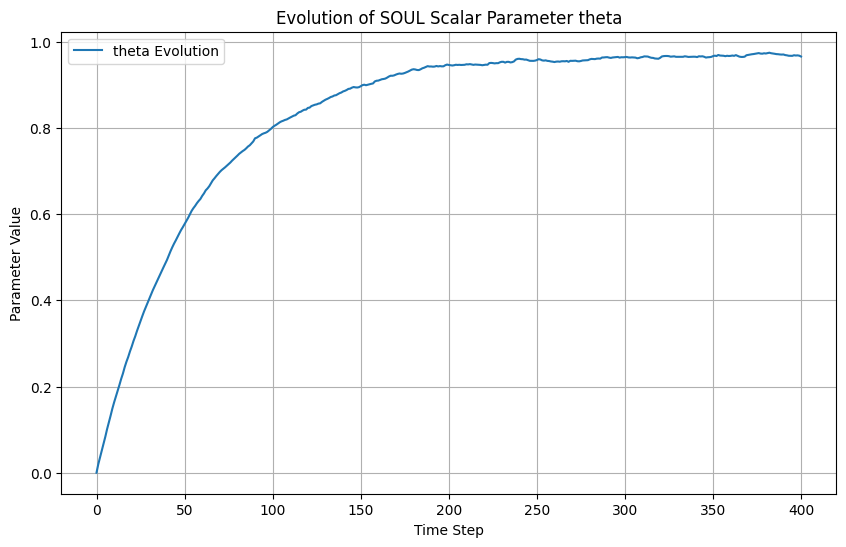

In [41]:
# Split data into 80/20 training and testing sets:
from sklearn.model_selection import train_test_split
ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2,
                                                random_state=0)

# Set approximation parameters as in our reference paper:
delta_step = 1e-2 # Step-size, same for ULA and Langevin in this case.
gamma_step = 1e-2
T = 400  # Number of steps.
M = 100  # Number of particles.
B = 0 # There is no burn-in in this example.

# Initialize parameter estimates and particle cloud, all at zero:
D = features[0, :].size  # Dimension of latent space.
th0 = np.array([0.0])  # Parameter estimate, initialized as a (1,1) float array (scalar).
X0 = np.zeros((D, M))  # Particle cloud.

# Run algorithm:
th_soul, x_soul = soul(log_p_grad_x, th0, X0, ltrain, ftrain, T, M, B, delta_step, gamma_step)

# Plot the results
plt.figure(figsize=(10, 6))

plt.plot(th_soul, label='theta Evolution')
plt.xlabel('Time Step')
plt.ylabel('Parameter Value')
plt.title('Evolution of SOUL Scalar Parameter theta')
plt.legend()
plt.grid(True)
plt.show()